# Medicare Claims Quantitative Analysis

Author: Stephen Lew

---

This code performs quantitative data analysis on a sample of the Centers for Medicare & Medicaid Services' 2008-2010 Data Entrepreneurs' Synthetic Public Use File.

Output from this program contains no sensitive information, PHI, nor PII.

---

**Contents**
- Section 1: Data Processing
- Section 2: Exploratory Data Analysis
- Section 3: Data Validation
- Section 4: Analysis
    - Table 1. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer
    - Figure 1. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer
    - Table 2. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by age
    - Table 3. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by end stage renal disease
    - Table 4. Multivariable regression analysis to examine predictors of Medicare spending
- Section 5: Methods and Limitations

In [1]:
import jinja2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import snowflake.connector
import statsmodels.api as sm
from dotenv import load_dotenv
from matplotlib.ticker import StrMethodFormatter

In [2]:
# Load environment variables from .env file
load_dotenv()

True

In [3]:
# Connect to Snowflake
if not all([os.getenv("SNOWFLAKE_USER"), os.getenv("SNOWFLAKE_PASSWORD"), os.getenv("SNOWFLAKE_ACCOUNT")]):
    raise EnvironmentError("Missing one or more Snowflake environment variables.")

try:
    conn = snowflake.connector.connect(
        user = os.getenv("SNOWFLAKE_USER"),
        password = os.getenv("SNOWFLAKE_PASSWORD"),
        account = os.getenv("SNOWFLAKE_ACCOUNT"),
        warehouse = os.getenv("SNOWFLAKE_WAREHOUSE"),
        database = os.getenv("SNOWFLAKE_DATABASE"),
        schema = os.getenv("SNOWFLAKE_SCHEMA")
    )
except Exception as e:
    print(f"Connection failed: {e}")
    raise

In [4]:
# Create a function to run a query on Snowflake and return the results as a Pandas dataframe
def query_to_pd(conn, sql):
    try:
        with conn.cursor() as cur:
            cur.execute(sql)
            return cur.fetch_pandas_all()
    except Exception as e:
        print(f"Query failed: {e}")
        raise

## Section 1: Data Processing

In [5]:
# Jinja templates for SQL queries
env = jinja2.Environment()

# Template for query to count rows
sql_template_row_count = env.from_string("""
SELECT COUNT(*) AS {{table}}_row_count
FROM {{table}}
""")

# Template for query to count columns
sql_template_col_count = env.from_string("""
SELECT COUNT(*) AS {{table}}_col_count
FROM information_schema.columns
WHERE UPPER(TABLE_NAME) = UPPER('{{table}}') AND UPPER(TABLE_SCHEMA) = UPPER('{{schema}}')
""")

# Template for query to count records missing a key ID
sql_template_missing_id_count = env.from_string("""
SELECT COUNT(*) AS {{table}}_missing_id_count
FROM {{table}}
WHERE {{missing_condition}}
""")

# Template for query to select distinct records
sql_template_distinct = env.from_string("""
SELECT DISTINCT {{columns}}
FROM {{table}}
""")

# Template for query for analysis tables
sql_analysis_table = env.from_string("""
WITH cte1 AS (
    SELECT
        {{grouping}},
        SUM(COALESCE(MEDREIMB, 0)) AS Medicare,
        SUM(COALESCE(BENRES, 0)) AS Beneficiary_Responsibility,
        SUM(COALESCE(NCH_PRMRY_PYR_CLM_PD_AMT, 0)) AS Primary_Payer
    FROM analysis2008
    GROUP BY {{grouping}}
    ORDER BY {{grouping}}
),
cte2 AS (
    SELECT *,
    Medicare + Beneficiary_Responsibility + Primary_Payer AS Total
    FROM cte1
)
SELECT *,
    (Medicare / Total) * 100 AS Medicare_Pct,
    (Beneficiary_Responsibility / Total) * 100 AS Beneficiary_Responsibility_Pct,
    (Primary_Payer / Total) * 100 AS Primary_Payer_Pct
FROM cte2
""")

In [6]:
# 2008 Beneficiary Summary File
df_beneficiary2008_row_count = query_to_pd(conn, sql_template_row_count.render(table = "beneficiary2008"))
df_beneficiary2008_row_count

,BENEFICIARY2008_ROW_COUNT
0,116352


In [7]:
df_beneficiary2008_col_count = query_to_pd(conn, sql_template_col_count.render(table = "beneficiary2008", schema = "public"))
df_beneficiary2008_col_count

,BENEFICIARY2008_COL_COUNT
0,32


In [8]:
# Quality check: Are there any cases missing a key ID?
df_beneficiary2008_missing_id_count = query_to_pd(conn, sql_template_missing_id_count.render(
    table = "beneficiary2008",
    missing_condition = "DESYNPUF_ID IS NULL"
))
beneficiary2008_missing_id_count = df_beneficiary2008_missing_id_count.iloc[0, 0]
print(f"There are {beneficiary2008_missing_id_count} cases where DESYNPUF_ID is missing.")

There are 0 cases where DESYNPUF_ID is missing.


In [9]:
# 2008-2010 Inpatient Claims
df_inpatient_row_count = query_to_pd(conn, sql_template_row_count.render(table = "inpatient"))
df_inpatient_row_count

,INPATIENT_ROW_COUNT
0,66773


In [10]:
df_inpatient_col_count = query_to_pd(conn, sql_template_col_count.render(table = "inpatient", schema = "public"))
df_inpatient_col_count

,INPATIENT_COL_COUNT
0,81


In [11]:
# Quality check: Are there any cases missing a key ID?
df_inpatient_missing_id_count = query_to_pd(conn, sql_template_missing_id_count.render(
    table = "inpatient",
    missing_condition = "DESYNPUF_ID IS NULL OR CLM_ID IS NULL"
))
inpatient_missing_id_count = df_inpatient_missing_id_count.iloc[0, 0]
print(f"There are {inpatient_missing_id_count} cases where DESYNPUF_ID is missing or CLM_ID is missing.")

There are 0 cases where DESYNPUF_ID is missing or CLM_ID is missing.


In [12]:
# 2008-2010 Outpatient Claims
df_outpatient_row_count = query_to_pd(conn, sql_template_row_count.render(table = "outpatient"))
df_outpatient_row_count

,OUTPATIENT_ROW_COUNT
0,790790


In [13]:
df_outpatient_col_count = query_to_pd(conn, sql_template_col_count.render(table = "outpatient", schema = "public"))
df_outpatient_col_count

,OUTPATIENT_COL_COUNT
0,76


In [14]:
# Quality check: Are there any cases missing a key ID?
df_outpatient_missing_id_count = query_to_pd(conn, sql_template_missing_id_count.render(
    table = "outpatient",
    missing_condition = "DESYNPUF_ID IS NULL OR CLM_ID IS NULL"
))
outpatient_missing_id_count = df_outpatient_missing_id_count.iloc[0, 0]
print(f"There are {outpatient_missing_id_count} cases where DESYNPUF_ID is missing or CLM_ID is missing.")

There are 0 cases where DESYNPUF_ID is missing or CLM_ID is missing.


In [15]:
# Process the 2008 Beneficiary Summary File
#   Convert date variables from YYYYMMDD numeric values to date values (BENE_BIRTH_DATE, BENE_DEATH_DATE)
#   Create variable indicating beneficiary death (BENEFICIARY_DEAD)
#   Create variable for beneficiary age (AGE)
#   Create a categorical variable for beneficiary age (AGE_CATEGORIES)
sql_beneficiary2008_process = """
DROP TABLE IF EXISTS beneficiary2008_processed;
CREATE TABLE beneficiary2008_processed AS
    WITH process1 AS (
        SELECT *,
            TO_DATE(TO_VARCHAR(BENE_BIRTH_DT), 'YYYYMMDD') AS BENE_BIRTH_DATE,
            TO_DATE(TO_VARCHAR(BENE_DEATH_DT), 'YYYYMMDD') AS BENE_DEATH_DATE,
            (BENE_DEATH_DT IS NOT NULL) AS BENEFICIARY_DEAD
        FROM beneficiary2008
    ),
    process2 AS (
        SELECT *,
            (CASE
                WHEN BENEFICIARY_DEAD THEN DATEDIFF(day, BENE_BIRTH_DATE, BENE_DEATH_DATE) / 365.25
                ELSE DATEDIFF(day, BENE_BIRTH_DATE, '2008-12-31') / 365.25
            END) AS AGE
        FROM process1
    )
    SELECT *,
        (CASE
            WHEN AGE < 40 THEN 1
            WHEN AGE < 60 THEN 2
            WHEN AGE < 80 THEN 3
            ELSE 4
         END) AS AGE_CATEGORIES
    FROM process2;
"""

conn.execute_string(sql_beneficiary2008_process)

In [16]:
# Validate BENE_BIRTH_DATE
df_chkder_bene_birth_date = query_to_pd(conn, sql_template_distinct.render(table = "beneficiary2008_processed", columns = "BENE_BIRTH_DT, BENE_BIRTH_DATE"))
df_chkder_bene_birth_date

,BENE_BIRTH_DT,BENE_BIRTH_DATE
0,19430101,1943-01-01
1,19290601,1929-06-01
2,19340501,1934-05-01
3,19320701,1932-07-01
4,19340401,1934-04-01
...,...,...
895,19770901,1977-09-01
896,19651001,1965-10-01
897,19680901,1968-09-01
898,19780301,1978-03-01


In [17]:
# Validate BENE_DEATH_DATE and BENEFICIARY_DEAD
df_chkder_bene_death_date = query_to_pd(conn, sql_template_distinct.render(table = "beneficiary2008_processed", columns = "BENE_DEATH_DT, BENE_DEATH_DATE, BENEFICIARY_DEAD"))
df_chkder_bene_death_date

,BENE_DEATH_DT,BENE_DEATH_DATE,BENEFICIARY_DEAD
0,NaN,None,False
1,20081001.0,2008-10-01,True
2,20080901.0,2008-09-01,True
3,20080401.0,2008-04-01,True
4,20080601.0,2008-06-01,True
5,20080801.0,2008-08-01,True
6,20080701.0,2008-07-01,True
7,20080201.0,2008-02-01,True
8,20080501.0,2008-05-01,True
9,20080101.0,2008-01-01,True


In [18]:
# Validate AGE and AGE_CATEGORIES
df_chkder_age = query_to_pd(conn, sql_template_distinct.render(table = "beneficiary2008_processed", columns = "BENE_BIRTH_DATE, BENE_DEATH_DATE, AGE, AGE_CATEGORIES"))
df_chkder_age

,BENE_BIRTH_DATE,BENE_DEATH_DATE,AGE,AGE_CATEGORIES
0,1963-10-01,None,45.251198,2
1,1942-02-01,None,66.913073,3
2,1934-09-01,None,74.332649,3
3,1934-12-01,None,74.083504,3
4,1939-07-01,None,69.503080,3
...,...,...,...,...
2395,1931-07-01,2008-11-01,77.338809,3
2396,1942-04-01,2008-10-01,66.502396,3
2397,1928-12-01,2008-06-01,79.498973,3
2398,1949-05-01,2008-05-01,59.000684,2


In [19]:
# Process the 2008-2010 Inpatient Claims
#   Convert date variables from YYYYMMDD numeric values to date values (CLM_FROM_DATE, CLM_THRU_DATE, CLM_ADMSN_DATE, NCH_BENE_DSCHRG_DATE)
#   Create a variable identifying the type of claim (CLAIM_TYPE)
#   Create a variable identifying the year of the claim (CLAIM_YEAR)
#   Create a variable calculating the Medicare payment of a claim (MEDREIMB)
#   Create a variable calculating the beneficiary responsibility of a claim (BENRES)
sql_inpatient_process = """
DROP TABLE IF EXISTS inpatient_processed;
CREATE TABLE inpatient_processed AS
    WITH process1 AS (
        SELECT *,
            TO_DATE(TO_VARCHAR(CLM_FROM_DT), 'YYYYMMDD') AS CLM_FROM_DATE,
            TO_DATE(TO_VARCHAR(CLM_THRU_DT), 'YYYYMMDD') AS CLM_THRU_DATE,
            TO_DATE(TO_VARCHAR(CLM_ADMSN_DT), 'YYYYMMDD') AS CLM_ADMSN_DATE,
            TO_DATE(TO_VARCHAR(NCH_BENE_DSCHRG_DT), 'YYYYMMDD') AS NCH_BENE_DSCHRG_DATE,
            'Inpatient' AS CLAIM_TYPE,
            CLM_PMT_AMT + (CLM_PASS_THRU_PER_DIEM_AMT * CLM_UTLZTN_DAY_CNT) AS MEDREIMB,
            NCH_BENE_IP_DDCTBL_AMT + NCH_BENE_PTA_COINSRNC_LBLTY_AM + NCH_BENE_BLOOD_DDCTBL_LBLTY_AM AS BENRES
        FROM inpatient
    )
    SELECT *,
        YEAR(CLM_THRU_DATE) AS CLAIM_YEAR
    FROM process1;
"""

conn.execute_string(sql_inpatient_process)

In [20]:
# Validate CLM_FROM_DATE
df_chkder_clm_from_date = query_to_pd(conn, sql_template_distinct.render(table = "inpatient_processed", columns = "CLM_FROM_DT, CLM_FROM_DATE"))
df_chkder_clm_from_date

,CLM_FROM_DT,CLM_FROM_DATE
0,20100626.0,2010-06-26
1,20080919.0,2008-09-19
2,20100602.0,2010-06-02
3,20091209.0,2009-12-09
4,20081230.0,2008-12-30
...,...,...
1116,20100825.0,2010-08-25
1117,20101015.0,2010-10-15
1118,20071127.0,2007-11-27
1119,20101226.0,2010-12-26


In [21]:
# Validate CLM_THRU_DATE and CLAIM_YEAR
df_chkder_clm_thru_date = query_to_pd(conn, sql_template_distinct.render(table = "inpatient_processed", columns = "CLM_THRU_DT, CLM_THRU_DATE, CLAIM_YEAR"))
df_chkder_clm_thru_date

,CLM_THRU_DT,CLM_THRU_DATE,CLAIM_YEAR
0,20090120.0,2009-01-20,2009.0
1,20100119.0,2010-01-19,2010.0
2,20080526.0,2008-05-26,2008.0
3,20080626.0,2008-06-26,2008.0
4,20100319.0,2010-03-19,2010.0
...,...,...,...
1092,20100913.0,2010-09-13,2010.0
1093,20101216.0,2010-12-16,2010.0
1094,20101106.0,2010-11-06,2010.0
1095,20101122.0,2010-11-22,2010.0


In [22]:
# Validate CLM_ADMSN_DATE
df_chkder_clm_admsn_date = query_to_pd(conn, sql_template_distinct.render(table = "inpatient_processed", columns = "CLM_ADMSN_DT, CLM_ADMSN_DATE"))
df_chkder_clm_admsn_date

,CLM_ADMSN_DT,CLM_ADMSN_DATE
0,20090412,2009-04-12
1,20100522,2010-05-22
2,20090826,2009-08-26
3,20091207,2009-12-07
4,20090626,2009-06-26
...,...,...
1115,20091212,2009-12-12
1116,20101114,2010-11-14
1117,20101015,2010-10-15
1118,20100506,2010-05-06


In [23]:
# Validate NCH_BENE_DSCHRG_DATE
df_chkder_nch_bene_dschrg_date = query_to_pd(conn, sql_template_distinct.render(table = "inpatient_processed", columns = "NCH_BENE_DSCHRG_DT, NCH_BENE_DSCHRG_DATE"))
df_chkder_nch_bene_dschrg_date

,NCH_BENE_DSCHRG_DT,NCH_BENE_DSCHRG_DATE
0,20100701,2010-07-01
1,20100612,2010-06-12
2,20100907,2010-09-07
3,20100119,2010-01-19
4,20080526,2008-05-26
...,...,...
1091,20101124,2010-11-24
1092,20090908,2009-09-08
1093,20101112,2010-11-12
1094,20101030,2010-10-30


In [24]:
# Validate MEDREIMB
df_chkder_medreimb = query_to_pd(conn, sql_template_distinct.render(table = "inpatient_processed", columns = "CLM_PMT_AMT, CLM_PASS_THRU_PER_DIEM_AMT, CLM_UTLZTN_DAY_CNT, MEDREIMB"))
df_chkder_medreimb

,CLM_PMT_AMT,CLM_PASS_THRU_PER_DIEM_AMT,CLM_UTLZTN_DAY_CNT,MEDREIMB
0,14000.0,0.0,21.0,14000.0
1,2000.0,0.0,3.0,2000.0
2,13000.0,0.0,3.0,13000.0
3,3000.0,0.0,2.0,3000.0
4,57000.0,0.0,11.0,57000.0
...,...,...,...,...
7185,33000.0,100.0,1.0,33100.0
7186,26000.0,50.0,3.0,26150.0
7187,2000.0,0.0,40.0,2000.0
7188,34000.0,70.0,11.0,34770.0


In [25]:
# Validate BENRES
df_chkder_benres = query_to_pd(conn, sql_template_distinct.render(table = "inpatient_processed", columns = "NCH_BENE_IP_DDCTBL_AMT, NCH_BENE_PTA_COINSRNC_LBLTY_AM, NCH_BENE_BLOOD_DDCTBL_LBLTY_AM, BENRES"))
df_chkder_benres

,NCH_BENE_IP_DDCTBL_AMT,NCH_BENE_PTA_COINSRNC_LBLTY_AM,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,BENRES
0,1100.0,0.0,0.0,1100.0
1,1024.0,0.0,200.0,1224.0
2,1024.0,0.0,300.0,1324.0
3,1100.0,500.0,0.0,1600.0
4,1100.0,300.0,0.0,1400.0
...,...,...,...,...
152,1100.0,0.0,500.0,1600.0
153,1024.0,19000.0,0.0,20024.0
154,NaN,18000.0,0.0,NaN
155,1024.0,29000.0,0.0,30024.0


In [26]:
# Process the 2008-2010 Outpatient Claims
#   Convert date variables from YYYYMMDD numeric values to date values (CLM_FROM_DATE, CLM_THRU_DATE)
#   Create a variable identifying the type of claim (CLAIM_TYPE)
#   Create a variable identifying the year of the claim (CLAIM_YEAR)
#   Create a variable calculating the Medicare payment of a claim (MEDREIMB)
#   Create a variable calculating the beneficiary responsibility of a claim (BENRES)
sql_outpatient_process = """
DROP TABLE IF EXISTS outpatient_processed;
CREATE TABLE outpatient_processed AS
    WITH process1 AS (
        SELECT *,
            TO_DATE(TO_VARCHAR(CLM_FROM_DT), 'YYYYMMDD') AS CLM_FROM_DATE,
            TO_DATE(TO_VARCHAR(CLM_THRU_DT), 'YYYYMMDD') AS CLM_THRU_DATE,
            'Outpatient' AS CLAIM_TYPE,
            CLM_PMT_AMT AS MEDREIMB,
            NCH_BENE_BLOOD_DDCTBL_LBLTY_AM + NCH_BENE_PTB_DDCTBL_AMT + NCH_BENE_PTB_COINSRNC_AMT AS BENRES
        FROM outpatient
    )
    SELECT *,
        YEAR(CLM_THRU_DATE) AS CLAIM_YEAR
    FROM process1;
"""

conn.execute_string(sql_outpatient_process)

In [27]:
# Validate CLM_FROM_DATE
df_chkder_clm_from_date2 = query_to_pd(conn, sql_template_distinct.render(table = "outpatient_processed", columns = "CLM_FROM_DT, CLM_FROM_DATE"))
df_chkder_clm_from_date2

,CLM_FROM_DT,CLM_FROM_DATE
0,20090630.0,2009-06-30
1,20081227.0,2008-12-27
2,20090626.0,2009-06-26
3,20080904.0,2008-09-04
4,20090223.0,2009-02-23
...,...,...
1112,20091004.0,2009-10-04
1113,20080220.0,2008-02-20
1114,20100608.0,2010-06-08
1115,20101121.0,2010-11-21


In [28]:
# Validate CLM_THRU_DATE and CLAIM_YEAR
df_chkder_clm_thru_date2 = query_to_pd(conn, sql_template_distinct.render(table = "outpatient_processed", columns = "CLM_THRU_DT, CLM_THRU_DATE, CLAIM_YEAR"))
df_chkder_clm_thru_date2

,CLM_THRU_DT,CLM_THRU_DATE,CLAIM_YEAR
0,20081127.0,2008-11-27,2008.0
1,20081122.0,2008-11-22,2008.0
2,20091221.0,2009-12-21,2009.0
3,20100215.0,2010-02-15,2010.0
4,20091227.0,2009-12-27,2009.0
...,...,...,...
1092,20100828.0,2010-08-28,2010.0
1093,20101102.0,2010-11-02,2010.0
1094,20090424.0,2009-04-24,2009.0
1095,20090918.0,2009-09-18,2009.0


In [29]:
# Validate MEDREIMB
df_chkder_medreimb2 = query_to_pd(conn, sql_template_distinct.render(table = "outpatient_processed", columns = "CLM_PMT_AMT, MEDREIMB"))
df_chkder_medreimb2

,CLM_PMT_AMT,MEDREIMB
0,50.0,50.0
1,90.0,90.0
2,2900.0,2900.0
3,2700.0,2700.0
4,3100.0,3100.0
5,2800.0,2800.0
6,1100.0,1100.0
7,1300.0,1300.0
8,700.0,700.0
9,500.0,500.0


In [30]:
# Validate BENRES
df_chkder_benres2 = query_to_pd(conn, sql_template_distinct.render(table = "outpatient_processed", columns = "NCH_BENE_BLOOD_DDCTBL_LBLTY_AM, NCH_BENE_PTB_DDCTBL_AMT, NCH_BENE_PTB_COINSRNC_AMT, BENRES"))
df_chkder_benres2

,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,NCH_BENE_PTB_DDCTBL_AMT,NCH_BENE_PTB_COINSRNC_AMT,BENRES
0,300.0,0.0,30.0,330.0
1,0.0,0.0,600.0,600.0
2,0.0,0.0,300.0,300.0
3,0.0,100.0,100.0,200.0
4,0.0,0.0,70.0,70.0
...,...,...,...,...
265,0.0,200.0,1000.0,1200.0
266,0.0,80.0,700.0,780.0
267,0.0,20.0,900.0,920.0
268,0.0,30.0,800.0,830.0


In [31]:
# Quality check: Are there any instances where the claim end date is before the claim start date?
sql_claim_date_check_inpatient = """
SELECT COUNT(*) AS claim_end_before_start
FROM inpatient_processed
WHERE CLM_THRU_DATE < CLM_FROM_DATE
"""

df_claim_date_check_inpatient = query_to_pd(conn, sql_claim_date_check_inpatient)
claim_date_check_inpatient = df_claim_date_check_inpatient.iloc[0, 0]
print(f"There are {claim_date_check_inpatient} inpatient claims where the claim end date is before the claim start date.")

There are 0 inpatient claims where the claim end date is before the claim start date.


In [32]:
sql_claim_date_check_outpatient = """
SELECT COUNT(*) AS claim_end_before_start
FROM outpatient_processed
WHERE CLM_THRU_DATE < CLM_FROM_DATE
"""

df_claim_date_check_outpatient = query_to_pd(conn, sql_claim_date_check_outpatient)
claim_date_check_outpatient = df_claim_date_check_outpatient.iloc[0, 0]
print(f"There are {claim_date_check_outpatient} outpatient claims where the claim end date is before the claim start date.")

There are 0 outpatient claims where the claim end date is before the claim start date.


## Section 2: Exploratory Data Analysis

In [33]:
sql_beneficiary2008_eda = """
SELECT 
    DESYNPUF_ID,
    BENE_BIRTH_DATE,
    BENE_SEX_IDENT_CD,
    BENE_RACE_CD,
    BENE_ESRD_IND,
    SP_ALZHDMTA,
    SP_CHF,
    SP_CHRNKIDN,
    SP_CNCR,
    SP_COPD,
    SP_DEPRESSN,
    SP_DIABETES,
    SP_ISCHMCHT,
    SP_OSTEOPRS,
    SP_RA_OA,
    SP_STRKETIA,
    BENEFICIARY_DEAD,
    AGE,
    AGE_CATEGORIES
FROM beneficiary2008_processed
"""

df_beneficiary2008_eda = query_to_pd(conn, sql_beneficiary2008_eda)

In [34]:
# Summary statistics of select continuous variables
df_beneficiary2008_eda["BENE_BIRTH_DATE"] = pd.to_datetime(df_beneficiary2008_eda["BENE_BIRTH_DATE"])
df_beneficiary2008_eda[["BENE_BIRTH_DATE"]].describe()

,BENE_BIRTH_DATE
count,116352
mean,1936-10-23 11:01:49.158415872
min,1909-01-01 00:00:00
25%,1928-11-01 00:00:00
50%,1936-05-01 00:00:00
75%,1942-03-01 00:00:00
max,1983-12-01 00:00:00


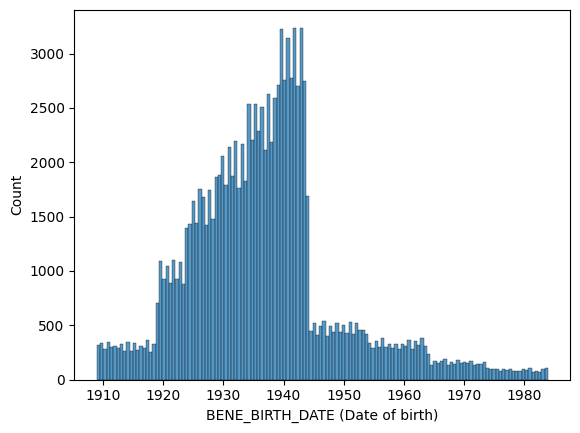

In [35]:
sns.histplot(df_beneficiary2008_eda, x = "BENE_BIRTH_DATE")
plt.xlabel("BENE_BIRTH_DATE (Date of birth)")
plt.show()

In [36]:
df_beneficiary2008_eda[["AGE"]].describe()

,AGE
count,116352.000000
mean,72.179253
std,12.508227
min,25.084189
25%,66.836413
50%,72.668036
75%,80.164271
max,99.997262


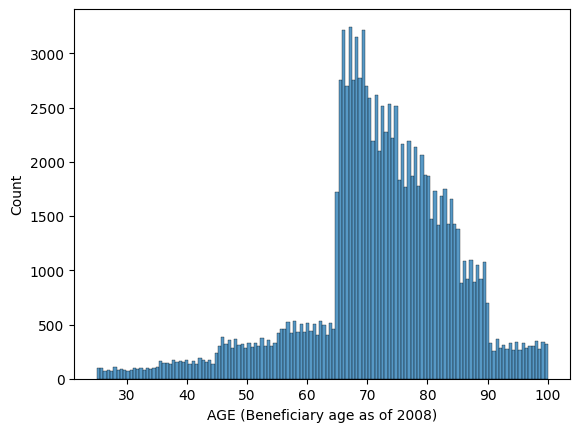

In [37]:
sns.histplot(df_beneficiary2008_eda, x = "AGE")
plt.xlabel("AGE (Beneficiary age as of 2008)")
plt.show()

BENE_SEX_IDENT_CD (Sex)
FREQUENCY
'1' = 'Male'      52005
'2' = 'Female'    64347
Name: count, dtype: int64
PERCENT
'1' = 'Male'      44.7
'2' = 'Female'    55.3
Name: proportion, dtype: float64


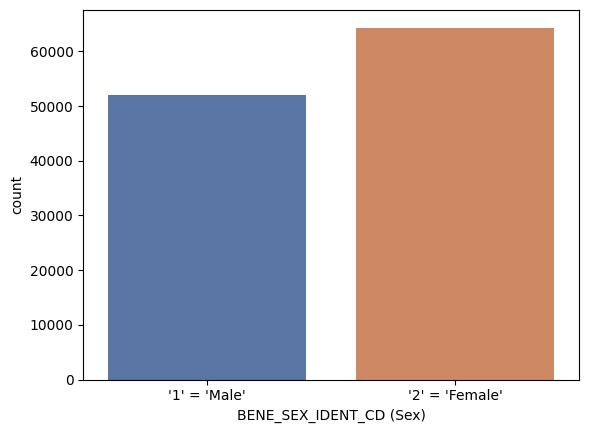

In [38]:
# Frequency distributions of select categorical variables
def freqdist(catvar, catvarlab):
    df_beneficiary2008_eda["FREQUENCY"] = df_beneficiary2008_eda[f"{catvar}"].map(mapping)
    df_beneficiary2008_eda["PERCENT"] = df_beneficiary2008_eda["FREQUENCY"]
    print(f"{catvarlab}")
    print(df_beneficiary2008_eda["FREQUENCY"].value_counts().sort_index())
    print(df_beneficiary2008_eda["PERCENT"].value_counts(normalize = True).mul(100).round(1).sort_index())
    category_order = sorted(df_beneficiary2008_eda["FREQUENCY"].unique())
    sns.countplot(df_beneficiary2008_eda, x = "FREQUENCY", hue = "FREQUENCY", order = category_order, palette = "deep", legend = False)
    plt.xlabel(f"{catvarlab}")
    plt.show()

    return None

mapping = {
    "1": "'1' = 'Male'",
    "2": "'2' = 'Female'"
}
freqdist(catvar = "BENE_SEX_IDENT_CD", catvarlab = "BENE_SEX_IDENT_CD (Sex)")

BENE_RACE_CD (Beneficiary Race Code)
FREQUENCY
'1' = 'White'       96349
'2' = 'Black'       12343
'3' = 'Others'       4931
'5' = 'Hispanic'     2729
Name: count, dtype: int64
PERCENT
'1' = 'White'       82.8
'2' = 'Black'       10.6
'3' = 'Others'       4.2
'5' = 'Hispanic'     2.3
Name: proportion, dtype: float64


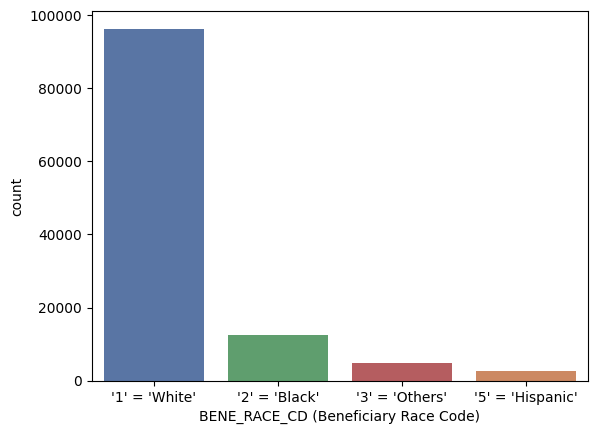

In [39]:
mapping = {
    "1": "'1' = 'White'",
    "2": "'2' = 'Black'",
    "3": "'3' = 'Others'",
    "5": "'5' = 'Hispanic'"
}
freqdist(catvar = "BENE_RACE_CD", catvarlab = "BENE_RACE_CD (Beneficiary Race Code)")

BENE_ESRD_IND (End stage renal disease Indicator)
FREQUENCY
'0' = 'No'     108091
'Y' = 'Yes'      8261
Name: count, dtype: int64
PERCENT
'0' = 'No'     92.9
'Y' = 'Yes'     7.1
Name: proportion, dtype: float64


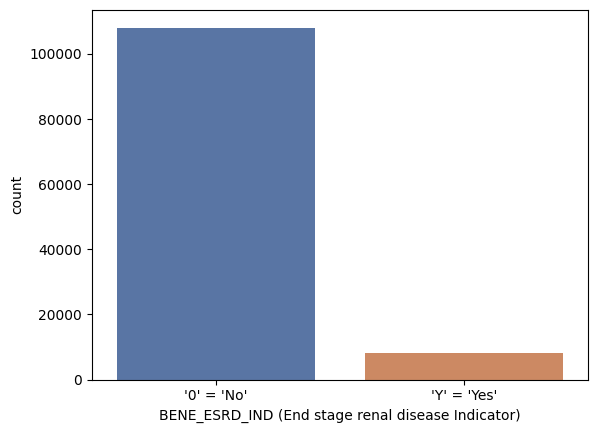

In [40]:
mapping = {
    "0": "'0' = 'No'",
    "Y": "'Y' = 'Yes'"
}
freqdist(catvar = "BENE_ESRD_IND", catvarlab = "BENE_ESRD_IND (End stage renal disease Indicator)")

SP_ALZHDMTA (Chronic Condition: Alzheimer or related disorders or senile)
FREQUENCY
1 = 'Yes'    22410
2 = 'No'     93942
Name: count, dtype: int64
PERCENT
1 = 'Yes'    19.3
2 = 'No'     80.7
Name: proportion, dtype: float64


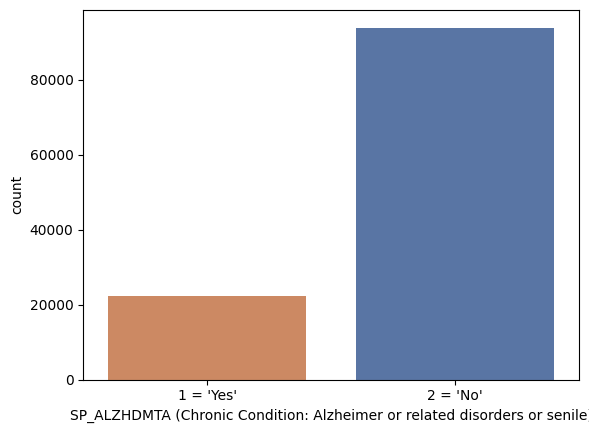

SP_CHF (Chronic Condition: Heart Failure)
FREQUENCY
1 = 'Yes'    33155
2 = 'No'     83197
Name: count, dtype: int64
PERCENT
1 = 'Yes'    28.5
2 = 'No'     71.5
Name: proportion, dtype: float64


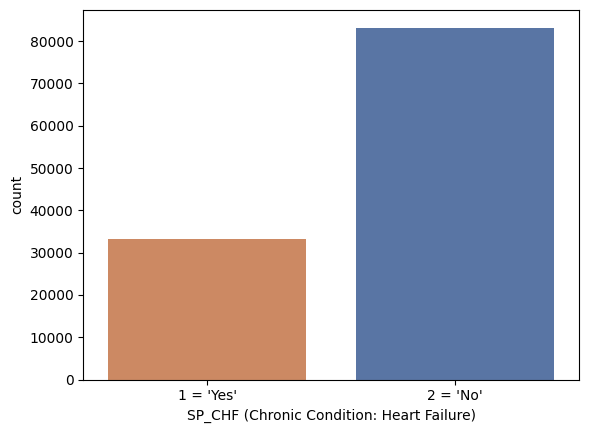

SP_CHRNKIDN (Chronic Condition: Chronic Kidney Disease)
FREQUENCY
1 = 'Yes'    18686
2 = 'No'     97666
Name: count, dtype: int64
PERCENT
1 = 'Yes'    16.1
2 = 'No'     83.9
Name: proportion, dtype: float64


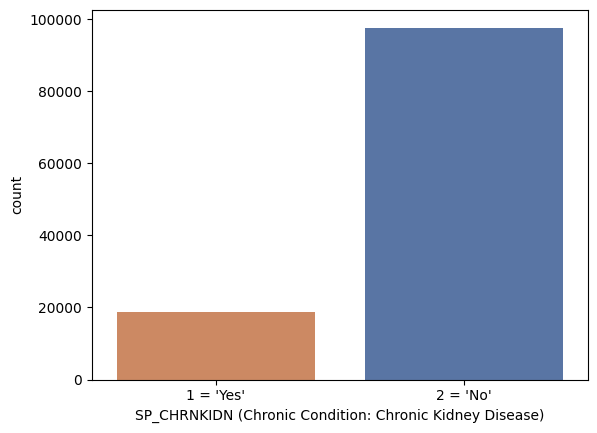

SP_CNCR (Chronic Condition: Cancer)
FREQUENCY
1 = 'Yes'      7415
2 = 'No'     108937
Name: count, dtype: int64
PERCENT
1 = 'Yes'     6.4
2 = 'No'     93.6
Name: proportion, dtype: float64


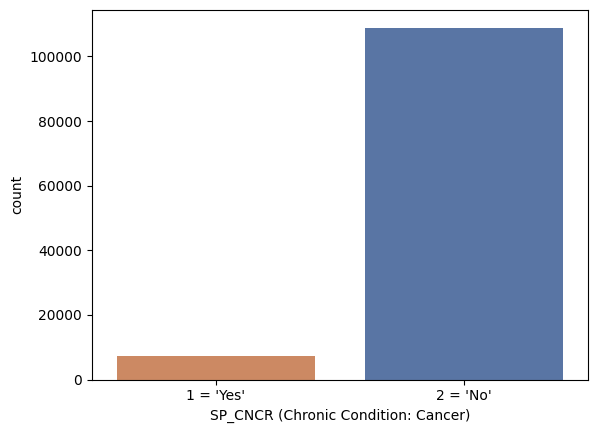

SP_COPD (Chronic Condition: Chronic Obstructive Pulmonary Disease)
FREQUENCY
1 = 'Yes'     15743
2 = 'No'     100609
Name: count, dtype: int64
PERCENT
1 = 'Yes'    13.5
2 = 'No'     86.5
Name: proportion, dtype: float64


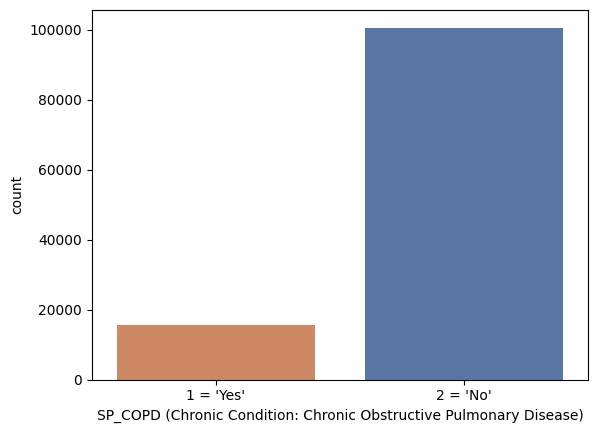

SP_DEPRESSN (Chronic Condition: Depression)
FREQUENCY
1 = 'Yes'    24840
2 = 'No'     91512
Name: count, dtype: int64
PERCENT
1 = 'Yes'    21.3
2 = 'No'     78.7
Name: proportion, dtype: float64


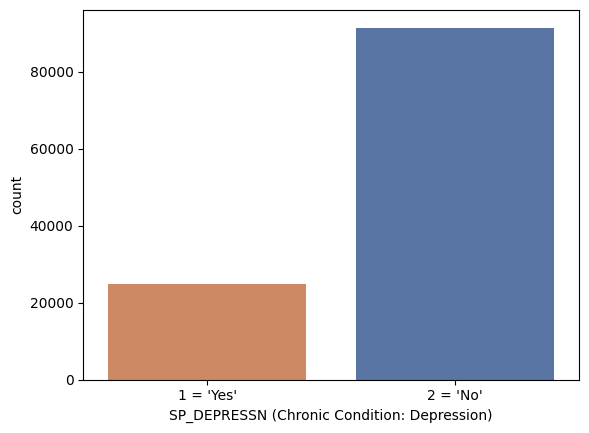

SP_DIABETES (Chronic Condition: Diabetes)
FREQUENCY
1 = 'Yes'    44060
2 = 'No'     72292
Name: count, dtype: int64
PERCENT
1 = 'Yes'    37.9
2 = 'No'     62.1
Name: proportion, dtype: float64


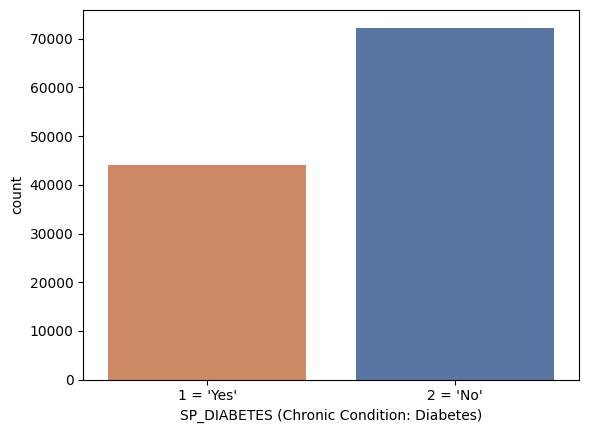

SP_ISCHMCHT (Chronic Condition: Ischemic Heart Disease)
FREQUENCY
1 = 'Yes'    48942
2 = 'No'     67410
Name: count, dtype: int64
PERCENT
1 = 'Yes'    42.1
2 = 'No'     57.9
Name: proportion, dtype: float64


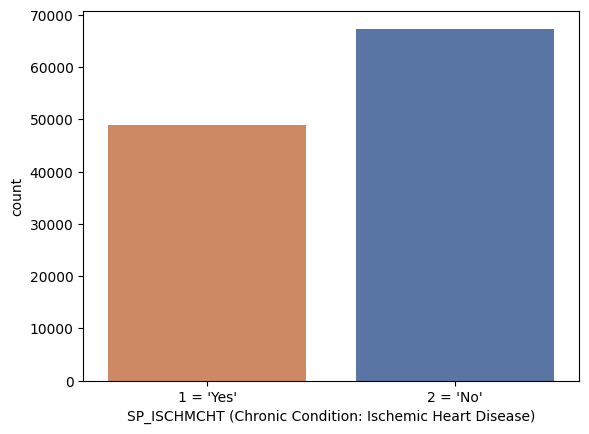

SP_OSTEOPRS (Chronic Condition: Osteoporosis)
FREQUENCY
1 = 'Yes'    20177
2 = 'No'     96175
Name: count, dtype: int64
PERCENT
1 = 'Yes'    17.3
2 = 'No'     82.7
Name: proportion, dtype: float64


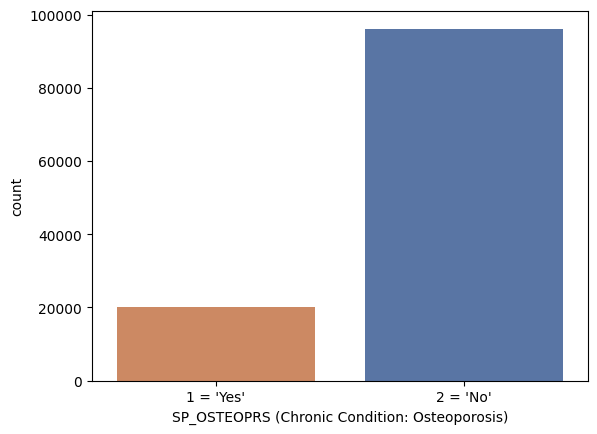

SP_RA_OA (Chronic Condition: Rheumatoid Arthritis or Osteoarthritis (RA/OA))
FREQUENCY
1 = 'Yes'    17916
2 = 'No'     98436
Name: count, dtype: int64
PERCENT
1 = 'Yes'    15.4
2 = 'No'     84.6
Name: proportion, dtype: float64


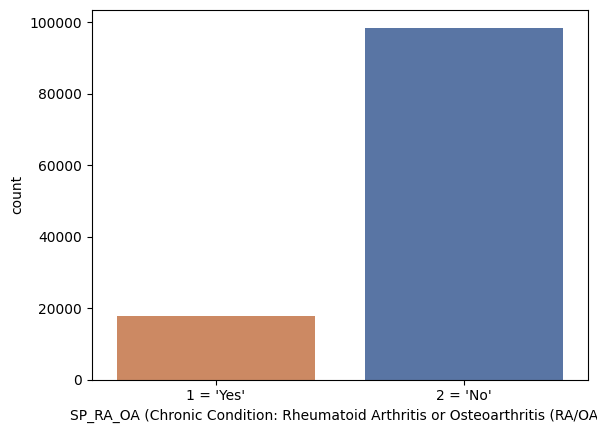

SP_STRKETIA (Chronic Condition: Stroke/transient Ischemic Attack)
FREQUENCY
1 = 'Yes'      5223
2 = 'No'     111129
Name: count, dtype: int64
PERCENT
1 = 'Yes'     4.5
2 = 'No'     95.5
Name: proportion, dtype: float64


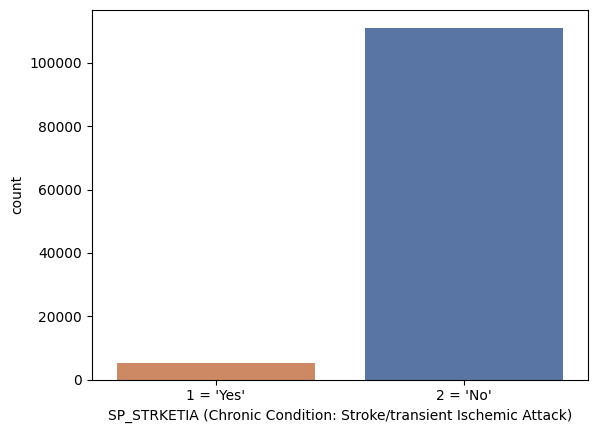

In [41]:
mapping = {
    1: "1 = 'Yes'",
    2: "2 = 'No'"
}
freqdist(catvar = "SP_ALZHDMTA", catvarlab = "SP_ALZHDMTA (Chronic Condition: Alzheimer or related disorders or senile)")
freqdist(catvar = "SP_CHF", catvarlab = "SP_CHF (Chronic Condition: Heart Failure)")
freqdist(catvar = "SP_CHRNKIDN", catvarlab = "SP_CHRNKIDN (Chronic Condition: Chronic Kidney Disease)")
freqdist(catvar = "SP_CNCR", catvarlab = "SP_CNCR (Chronic Condition: Cancer)")
freqdist(catvar = "SP_COPD", catvarlab = "SP_COPD (Chronic Condition: Chronic Obstructive Pulmonary Disease)")
freqdist(catvar = "SP_DEPRESSN", catvarlab = "SP_DEPRESSN (Chronic Condition: Depression)")
freqdist(catvar = "SP_DIABETES", catvarlab = "SP_DIABETES (Chronic Condition: Diabetes)")
freqdist(catvar = "SP_ISCHMCHT", catvarlab = "SP_ISCHMCHT (Chronic Condition: Ischemic Heart Disease)")
freqdist(catvar = "SP_OSTEOPRS", catvarlab = "SP_OSTEOPRS (Chronic Condition: Osteoporosis)")
freqdist(catvar = "SP_RA_OA", catvarlab = "SP_RA_OA (Chronic Condition: Rheumatoid Arthritis or Osteoarthritis (RA/OA))")
freqdist(catvar = "SP_STRKETIA", catvarlab = "SP_STRKETIA (Chronic Condition: Stroke/transient Ischemic Attack)")

BENEFICIARY_DEAD (Beneficiary is dead)
FREQUENCY
BENEFICIARY_DEAD
False    114538
True       1814
Name: count, dtype: int64
PERCENT
BENEFICIARY_DEAD
False    98.4
True      1.6
Name: proportion, dtype: float64


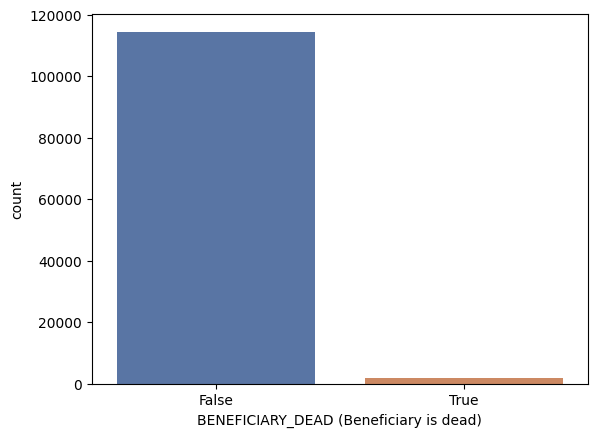

In [42]:
print("BENEFICIARY_DEAD (Beneficiary is dead)")
print("FREQUENCY")
print(df_beneficiary2008_eda["BENEFICIARY_DEAD"].value_counts().sort_index())
print("PERCENT")
print(df_beneficiary2008_eda["BENEFICIARY_DEAD"].value_counts(normalize = True).mul(100).round(1).sort_index())
sns.countplot(df_beneficiary2008_eda, x = "BENEFICIARY_DEAD", hue = "BENEFICIARY_DEAD", palette = "deep", legend = False)
plt.xlabel("BENEFICIARY_DEAD (Beneficiary is dead)")
plt.show()

AGE_CATEGORIES (Beneficiary age as of 2008 (Categorical))
FREQUENCY
0 to lt 40      3028
40 to lt 60    11779
60 to lt 80    72192
80+            29353
Name: count, dtype: int64
PERCENT
0 to lt 40      2.6
40 to lt 60    10.1
60 to lt 80    62.0
80+            25.2
Name: proportion, dtype: float64


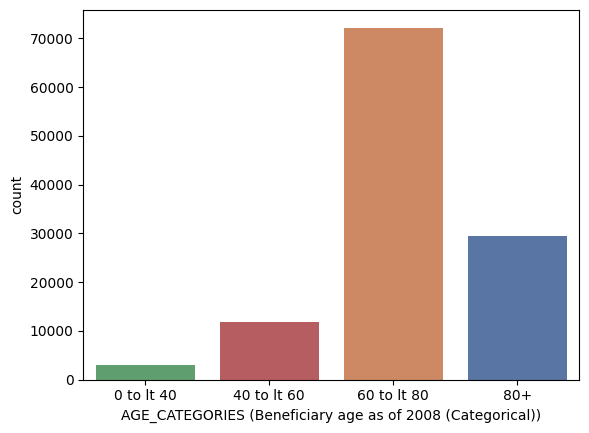

In [43]:
mapping = {
    1: "0 to lt 40",
    2: "40 to lt 60",
    3: "60 to lt 80",
    4: "80+"
}
freqdist(catvar = "AGE_CATEGORIES", catvarlab = "AGE_CATEGORIES (Beneficiary age as of 2008 (Categorical))")

In [44]:
# Create the analysis table
#   Append outpatient claims to inpatient claims and keep only the claims in 2008
#   Then merge claims data to beneficiary data
sql_create_analysis_table = """
DROP TABLE IF EXISTS analysis2008;
CREATE TABLE analysis2008 AS
    WITH claims2008 AS (
        SELECT *
        FROM (
            SELECT 
                DESYNPUF_ID,
                CLM_ID,
                SEGMENT,
                CLM_FROM_DT,
                CLM_THRU_DT,
                PRVDR_NUM,
                CLM_PMT_AMT,
                NCH_PRMRY_PYR_CLM_PD_AMT,
                AT_PHYSN_NPI,
                OP_PHYSN_NPI,
                OT_PHYSN_NPI,
                ADMTNG_ICD9_DGNS_CD,
                NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,
                ICD9_DGNS_CD_1,
                ICD9_DGNS_CD_2,
                ICD9_DGNS_CD_3,
                ICD9_DGNS_CD_4,
                ICD9_DGNS_CD_5,
                ICD9_DGNS_CD_6,
                ICD9_DGNS_CD_7,
                ICD9_DGNS_CD_8,
                ICD9_DGNS_CD_9,
                ICD9_DGNS_CD_10,
                ICD9_PRCDR_CD_1,
                ICD9_PRCDR_CD_2,
                ICD9_PRCDR_CD_3,
                ICD9_PRCDR_CD_4,
                ICD9_PRCDR_CD_5,
                ICD9_PRCDR_CD_6,
                HCPCS_CD_1,
                HCPCS_CD_2,
                HCPCS_CD_3,
                HCPCS_CD_4,
                HCPCS_CD_5,
                HCPCS_CD_6,
                HCPCS_CD_7,
                HCPCS_CD_8,
                HCPCS_CD_9,
                HCPCS_CD_10,
                HCPCS_CD_11,
                HCPCS_CD_12,
                HCPCS_CD_13,
                HCPCS_CD_14,
                HCPCS_CD_15,
                HCPCS_CD_16,
                HCPCS_CD_17,
                HCPCS_CD_18,
                HCPCS_CD_19,
                HCPCS_CD_20,
                HCPCS_CD_21,
                HCPCS_CD_22,
                HCPCS_CD_23,
                HCPCS_CD_24,
                HCPCS_CD_25,
                HCPCS_CD_26,
                HCPCS_CD_27,
                HCPCS_CD_28,
                HCPCS_CD_29,
                HCPCS_CD_30,
                HCPCS_CD_31,
                HCPCS_CD_32,
                HCPCS_CD_33,
                HCPCS_CD_34,
                HCPCS_CD_35,
                HCPCS_CD_36,
                HCPCS_CD_37,
                HCPCS_CD_38,
                HCPCS_CD_39,
                HCPCS_CD_40,
                HCPCS_CD_41,
                HCPCS_CD_42,
                HCPCS_CD_43,
                HCPCS_CD_44,
                HCPCS_CD_45,
                CLM_FROM_DATE,
                CLM_THRU_DATE,
                CLAIM_TYPE,
                CLAIM_YEAR,
                MEDREIMB,
                BENRES,
                CLM_ADMSN_DT,
                CLM_PASS_THRU_PER_DIEM_AMT,
                NCH_BENE_IP_DDCTBL_AMT,
                NCH_BENE_PTA_COINSRNC_LBLTY_AM,
                CLM_UTLZTN_DAY_CNT,
                NCH_BENE_DSCHRG_DT,
                CLM_DRG_CD,
                CLM_ADMSN_DATE,
                NCH_BENE_DSCHRG_DATE,
                NULL AS NCH_BENE_PTB_DDCTBL_AMT,
                NULL AS NCH_BENE_PTB_COINSRNC_AMT
            FROM inpatient_processed
            UNION ALL
            SELECT 
                DESYNPUF_ID,
                CLM_ID,
                SEGMENT,
                CLM_FROM_DT,
                CLM_THRU_DT,
                PRVDR_NUM,
                CLM_PMT_AMT,
                NCH_PRMRY_PYR_CLM_PD_AMT,
                AT_PHYSN_NPI,
                OP_PHYSN_NPI,
                OT_PHYSN_NPI,
                ADMTNG_ICD9_DGNS_CD,
                NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,
                ICD9_DGNS_CD_1,
                ICD9_DGNS_CD_2,
                ICD9_DGNS_CD_3,
                ICD9_DGNS_CD_4,
                ICD9_DGNS_CD_5,
                ICD9_DGNS_CD_6,
                ICD9_DGNS_CD_7,
                ICD9_DGNS_CD_8,
                ICD9_DGNS_CD_9,
                ICD9_DGNS_CD_10,
                ICD9_PRCDR_CD_1,
                ICD9_PRCDR_CD_2,
                ICD9_PRCDR_CD_3,
                ICD9_PRCDR_CD_4,
                ICD9_PRCDR_CD_5,
                ICD9_PRCDR_CD_6,
                HCPCS_CD_1,
                HCPCS_CD_2,
                HCPCS_CD_3,
                HCPCS_CD_4,
                HCPCS_CD_5,
                HCPCS_CD_6,
                HCPCS_CD_7,
                HCPCS_CD_8,
                HCPCS_CD_9,
                HCPCS_CD_10,
                HCPCS_CD_11,
                HCPCS_CD_12,
                HCPCS_CD_13,
                HCPCS_CD_14,
                HCPCS_CD_15,
                HCPCS_CD_16,
                HCPCS_CD_17,
                HCPCS_CD_18,
                HCPCS_CD_19,
                HCPCS_CD_20,
                HCPCS_CD_21,
                HCPCS_CD_22,
                HCPCS_CD_23,
                HCPCS_CD_24,
                HCPCS_CD_25,
                HCPCS_CD_26,
                HCPCS_CD_27,
                HCPCS_CD_28,
                HCPCS_CD_29,
                HCPCS_CD_30,
                HCPCS_CD_31,
                HCPCS_CD_32,
                HCPCS_CD_33,
                HCPCS_CD_34,
                HCPCS_CD_35,
                HCPCS_CD_36,
                HCPCS_CD_37,
                HCPCS_CD_38,
                HCPCS_CD_39,
                HCPCS_CD_40,
                HCPCS_CD_41,
                HCPCS_CD_42,
                HCPCS_CD_43,
                HCPCS_CD_44,
                HCPCS_CD_45,
                CLM_FROM_DATE,
                CLM_THRU_DATE,
                CLAIM_TYPE,
                CLAIM_YEAR,
                MEDREIMB,
                BENRES,
                NULL AS CLM_ADMSN_DT,
                NULL AS CLM_PASS_THRU_PER_DIEM_AMT,
                NULL AS NCH_BENE_IP_DDCTBL_AMT,
                NULL AS NCH_BENE_PTA_COINSRNC_LBLTY_AM,
                NULL AS CLM_UTLZTN_DAY_CNT,
                NULL AS NCH_BENE_DSCHRG_DT,
                NULL AS CLM_DRG_CD,
                NULL AS CLM_ADMSN_DATE,
                NULL AS NCH_BENE_DSCHRG_DATE,
                NCH_BENE_PTB_DDCTBL_AMT,
                NCH_BENE_PTB_COINSRNC_AMT
            FROM outpatient_processed
        )
        WHERE CLAIM_YEAR = 2008
    )
    SELECT ben.*,
        cl.CLM_ID,
        cl.SEGMENT,
        cl.CLM_FROM_DT,
        cl.CLM_THRU_DT,
        cl.PRVDR_NUM,
        cl.CLM_PMT_AMT,
        cl.NCH_PRMRY_PYR_CLM_PD_AMT,
        cl.AT_PHYSN_NPI,
        cl.OP_PHYSN_NPI,
        cl.OT_PHYSN_NPI,
        cl.ADMTNG_ICD9_DGNS_CD,
        cl.NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,
        cl.ICD9_DGNS_CD_1,
        cl.ICD9_DGNS_CD_2,
        cl.ICD9_DGNS_CD_3,
        cl.ICD9_DGNS_CD_4,
        cl.ICD9_DGNS_CD_5,
        cl.ICD9_DGNS_CD_6,
        cl.ICD9_DGNS_CD_7,
        cl.ICD9_DGNS_CD_8,
        cl.ICD9_DGNS_CD_9,
        cl.ICD9_DGNS_CD_10,
        cl.ICD9_PRCDR_CD_1,
        cl.ICD9_PRCDR_CD_2,
        cl.ICD9_PRCDR_CD_3,
        cl.ICD9_PRCDR_CD_4,
        cl.ICD9_PRCDR_CD_5,
        cl.ICD9_PRCDR_CD_6,
        cl.HCPCS_CD_1,
        cl.HCPCS_CD_2,
        cl.HCPCS_CD_3,
        cl.HCPCS_CD_4,
        cl.HCPCS_CD_5,
        cl.HCPCS_CD_6,
        cl.HCPCS_CD_7,
        cl.HCPCS_CD_8,
        cl.HCPCS_CD_9,
        cl.HCPCS_CD_10,
        cl.HCPCS_CD_11,
        cl.HCPCS_CD_12,
        cl.HCPCS_CD_13,
        cl.HCPCS_CD_14,
        cl.HCPCS_CD_15,
        cl.HCPCS_CD_16,
        cl.HCPCS_CD_17,
        cl.HCPCS_CD_18,
        cl.HCPCS_CD_19,
        cl.HCPCS_CD_20,
        cl.HCPCS_CD_21,
        cl.HCPCS_CD_22,
        cl.HCPCS_CD_23,
        cl.HCPCS_CD_24,
        cl.HCPCS_CD_25,
        cl.HCPCS_CD_26,
        cl.HCPCS_CD_27,
        cl.HCPCS_CD_28,
        cl.HCPCS_CD_29,
        cl.HCPCS_CD_30,
        cl.HCPCS_CD_31,
        cl.HCPCS_CD_32,
        cl.HCPCS_CD_33,
        cl.HCPCS_CD_34,
        cl.HCPCS_CD_35,
        cl.HCPCS_CD_36,
        cl.HCPCS_CD_37,
        cl.HCPCS_CD_38,
        cl.HCPCS_CD_39,
        cl.HCPCS_CD_40,
        cl.HCPCS_CD_41,
        cl.HCPCS_CD_42,
        cl.HCPCS_CD_43,
        cl.HCPCS_CD_44,
        cl.HCPCS_CD_45,
        cl.CLM_FROM_DATE,
        cl.CLM_THRU_DATE,
        cl.CLAIM_TYPE,
        cl.MEDREIMB,
        cl.BENRES,
        cl.CLM_ADMSN_DT,
        cl.CLM_PASS_THRU_PER_DIEM_AMT,
        cl.NCH_BENE_IP_DDCTBL_AMT,
        cl.NCH_BENE_PTA_COINSRNC_LBLTY_AM,
        cl.CLM_UTLZTN_DAY_CNT,
        cl.NCH_BENE_DSCHRG_DT,
        cl.CLM_DRG_CD,
        cl.CLM_ADMSN_DATE,
        cl.NCH_BENE_DSCHRG_DATE,
        cl.NCH_BENE_PTB_DDCTBL_AMT,
        cl.NCH_BENE_PTB_COINSRNC_AMT
    FROM beneficiary2008_processed ben
    INNER JOIN claims2008 cl
    ON ben.DESYNPUF_ID = cl.DESYNPUF_ID;
"""

conn.execute_string(sql_create_analysis_table)

## Section 3: Data Validation

In [45]:
# Validate the annual reimbursement amount variables in the beneficiary data by calculating the sum of the payment amounts across claims
# Inpatient claims
sql_validate_ip = """
WITH validate_ip AS (
    SELECT 
        DESYNPUF_ID,
        SUM(COALESCE(MEDREIMB, 0)) AS MEDREIMB_IP2,
        SUM(COALESCE(BENRES, 0)) AS BENRES_IP2,
        SUM(COALESCE(NCH_PRMRY_PYR_CLM_PD_AMT, 0)) AS PPPYMT_IP2
    FROM analysis2008
    WHERE CLAIM_TYPE = 'Inpatient'
    GROUP BY DESYNPUF_ID
    ORDER BY DESYNPUF_ID
),
validate_ip2 AS (
    SELECT
        an.DESYNPUF_ID,
        an.MEDREIMB_IP,
        an.BENRES_IP,
        an.PPPYMT_IP,
        val.MEDREIMB_IP2,
        val.BENRES_IP2,
        val.PPPYMT_IP2
    FROM analysis2008 an
    LEFT JOIN validate_ip val
    ON an.DESYNPUF_ID = val.DESYNPUF_ID
),
validate_ip3 AS (
    SELECT
        DESYNPUF_ID,
        MEDREIMB_IP,
        BENRES_IP,
        PPPYMT_IP,
        COALESCE(MEDREIMB_IP2, 0) AS MEDREIMB_IP2,
        COALESCE(BENRES_IP2, 0) AS BENRES_IP2,
        COALESCE(PPPYMT_IP2, 0) AS PPPYMT_IP2
    FROM validate_ip2
)
SELECT COUNT(*) AS diff_claim_totals
FROM validate_ip3
WHERE MEDREIMB_IP != MEDREIMB_IP2 OR BENRES_IP != BENRES_IP2 OR PPPYMT_IP != PPPYMT_IP2
"""

df_validate_ip = query_to_pd(conn, sql_validate_ip)
validate_ip = df_validate_ip.iloc[0, 0]
print(f"There are {validate_ip} inpatient claims where an annual reimbursement amount does not match the sum of the payment amounts across claims.")

There are 0 inpatient claims where an annual reimbursement amount does not match the sum of the payment amounts across claims.


In [46]:
# Outpatient claims
sql_validate_op = """
WITH validate_op AS (
    SELECT
        DESYNPUF_ID,
        SUM(COALESCE(MEDREIMB, 0)) AS MEDREIMB_OP2,
        SUM(COALESCE(BENRES, 0)) AS BENRES_OP2,
        SUM(COALESCE(NCH_PRMRY_PYR_CLM_PD_AMT, 0)) AS PPPYMT_OP2
    FROM analysis2008
    WHERE CLAIM_TYPE = 'Outpatient'
    GROUP BY DESYNPUF_ID
    ORDER BY DESYNPUF_ID
),
validate_op2 AS (
    SELECT
        an.DESYNPUF_ID,
        an.MEDREIMB_OP,
        an.BENRES_OP,
        an.PPPYMT_OP,
        val.MEDREIMB_OP2,
        val.BENRES_OP2,
        val.PPPYMT_OP2
    FROM analysis2008 an
    LEFT JOIN validate_op val
    ON an.DESYNPUF_ID = val.DESYNPUF_ID
),
validate_op3 AS (
    SELECT
        DESYNPUF_ID,
        MEDREIMB_OP,
        BENRES_OP,
        PPPYMT_OP,
        COALESCE(MEDREIMB_OP2, 0) AS MEDREIMB_OP2,
        COALESCE(BENRES_OP2, 0) AS BENRES_OP2,
        COALESCE(PPPYMT_OP2, 0) AS PPPYMT_OP2
    FROM validate_op2
)
SELECT COUNT(*) AS diff_claim_totals
FROM validate_op3
WHERE MEDREIMB_OP != MEDREIMB_OP2 OR BENRES_OP != BENRES_OP2 OR PPPYMT_OP != PPPYMT_OP2
"""

df_validate_op = query_to_pd(conn, sql_validate_op)
validate_op = df_validate_op.iloc[0, 0]
print(f"There are {validate_op} outpatient claims where an annual reimbursement amount does not match the sum of the payment amounts across claims.")

There are 0 outpatient claims where an annual reimbursement amount does not match the sum of the payment amounts across claims.


## Section 4: Analysis

### Table 1. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer

In [47]:
df_table1 = (query_to_pd(conn, sql_analysis_table.render(grouping = "CLAIM_TYPE"))
              .rename(columns = {"MEDICARE": "Medicare", "BENEFICIARY_RESPONSIBILITY": "Beneficiary_Responsibility", "PRIMARY_PAYER": "Primary_Payer", "TOTAL": "Total", "MEDICARE_PCT": "Medicare_Pct", "BENEFICIARY_RESPONSIBILITY_PCT": "Beneficiary_Responsibility_Pct", "PRIMARY_PAYER_PCT": "Primary_Payer_Pct"}))
df_table1 = df_table1.set_index("CLAIM_TYPE")
df_table1.to_csv("output/table1.csv")
df_figure1 = df_table1.copy()
df_table1 = df_table1.style.format({
    "Medicare": "${:,.0f}".format,
    "Beneficiary_Responsibility": "${:,.0f}".format,
    "Primary_Payer": "${:,.0f}".format,
    "Total": "${:,.0f}".format,
    "Medicare_Pct": "{:.1f}%".format,
    "Beneficiary_Responsibility_Pct": "{:.1f}%".format,
    "Primary_Payer_Pct": "{:.1f}%".format
})
print("Table 1. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer")
df_table1

Table 1. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer


,Medicare,Beneficiary_Responsibility,Primary_Payer,Total,Medicare_Pct,Beneficiary_Responsibility_Pct,Primary_Payer_Pct
CLAIM_TYPE,,,,,,,
Inpatient,"$257,624,360","$28,977,866","$11,535,400","$298,137,626",86.4%,9.7%,3.9%
Outpatient,"$72,397,300","$22,979,780","$2,993,060","$98,370,140",73.6%,23.4%,3.0%


### Figure 1. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer

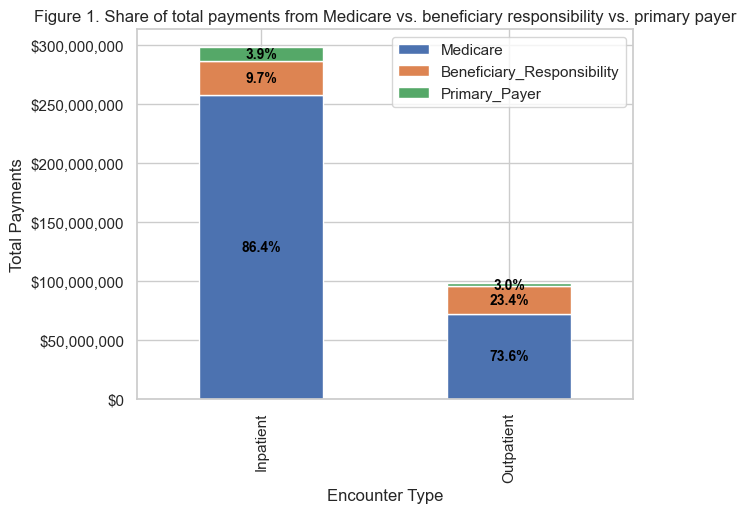

In [48]:
df_figure1 = df_figure1.drop(["Total", "Medicare_Pct", "Beneficiary_Responsibility_Pct", "Primary_Payer_Pct"], axis = 1)
sns.set_theme(style = "whitegrid")
ax = df_figure1.plot.bar(stacked = True)
ax.set_title("Figure 1. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer")
ax.set_xlabel("Encounter Type")
ax.set_ylabel("Total Payments")
plt.ticklabel_format(style = "plain", axis = "y")
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Add percentage labels
for i, claim_type in enumerate(df_figure1.index):
    total = df_figure1.loc[claim_type].sum()
    cumulative = 0

    for responsibility in df_figure1.columns:
        value = df_figure1.loc[claim_type, responsibility]
        pct = value / total * 100

        ax.text(
            i,
            cumulative + value / 2,
            f"{pct:.1f}%",
            ha='center',
            va='center',
            color='black',
            fontsize=10,
            fontweight='bold'
        )
        cumulative += value

fig1 = ax.get_figure()
fig1.savefig("output/figure1.png", bbox_inches = "tight")

### Table 2. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by age

In [49]:
df_table2 = (query_to_pd(conn, sql_analysis_table.render(grouping = "CLAIM_TYPE, AGE_CATEGORIES"))
             .rename(columns = {"MEDICARE": "Medicare", "BENEFICIARY_RESPONSIBILITY": "Beneficiary_Responsibility", "PRIMARY_PAYER": "Primary_Payer", "TOTAL": "Total", "MEDICARE_PCT": "Medicare_Pct", "BENEFICIARY_RESPONSIBILITY_PCT": "Beneficiary_Responsibility_Pct", "PRIMARY_PAYER_PCT": "Primary_Payer_Pct", "AGE_CATEGORIES": "AGE_GROUPS"}))
age_labels = {
    1: "0 to lt 40",
    2: "40 to lt 60",
    3: "60 to lt 80",
    4: "80+"
}
df_table2["AGE_GROUPS"] = df_table2["AGE_GROUPS"].map(age_labels)
df_table2 = df_table2.set_index(["CLAIM_TYPE", "AGE_GROUPS"])
df_table2.to_csv("output/table2.csv")
df_table2 = df_table2.style.format({
    "Medicare": "${:,.0f}".format,
    "Beneficiary_Responsibility": "${:,.0f}".format,
    "Primary_Payer": "${:,.0f}".format,
    "Total": "${:,.0f}".format,
    "Medicare_Pct": "{:.1f}%".format,
    "Beneficiary_Responsibility_Pct": "{:.1f}%".format,
    "Primary_Payer_Pct": "{:.1f}%".format
})
print("Table 2. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by age")
df_table2

Table 2. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by age


### Table 3. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by end stage renal disease

In [50]:
df_table3 = (query_to_pd(conn, sql_analysis_table.render(grouping = "CLAIM_TYPE, BENE_ESRD_IND"))
             .rename(columns = {"MEDICARE": "Medicare", "BENEFICIARY_RESPONSIBILITY": "Beneficiary_Responsibility", "PRIMARY_PAYER": "Primary_Payer", "TOTAL": "Total", "MEDICARE_PCT": "Medicare_Pct", "BENEFICIARY_RESPONSIBILITY_PCT": "Beneficiary_Responsibility_Pct", "PRIMARY_PAYER_PCT": "Primary_Payer_Pct", "BENE_ESRD_IND": "ESRD"}))
esrd_labels = {
    "0": "Does not have end stage renal disease",
    "Y": "Has end stage renal disease"
}
df_table3["ESRD"] = df_table3["ESRD"].map(esrd_labels)
df_table3 = df_table3.set_index(["CLAIM_TYPE", "ESRD"])
df_table3.to_csv("output/table3.csv")
df_table3 = df_table3.style.format({
    "Medicare": "${:,.0f}".format,
    "Beneficiary_Responsibility": "${:,.0f}".format,
    "Primary_Payer": "${:,.0f}".format,
    "Total": "${:,.0f}".format,
    "Medicare_Pct": "{:.1f}%".format,
    "Beneficiary_Responsibility_Pct": "{:.1f}%".format,
    "Primary_Payer_Pct": "{:.1f}%".format
})
print("Table 3. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by end stage renal disease")
df_table3

Table 3. Share of total payments from Medicare vs. beneficiary responsibility vs. primary payer by end stage renal disease


### Table 4. Multivariable regression analysis to examine predictors of Medicare spending

In [51]:
sql_model_prep = """
WITH prep1 AS (
    SELECT
        DESYNPUF_ID,
        MEDREIMB,
        AGE,
        (CASE
            WHEN BENE_ESRD_IND = 'Y' THEN 1
            ELSE 0
        END) AS ESRD_FLAG,
        (CASE
            WHEN CLAIM_TYPE = 'Inpatient' THEN 1
            ELSE 0
         END) AS INPATIENT_FLAG
    FROM analysis2008
)
SELECT
    DESYNPUF_ID,
    SUM(COALESCE(MEDREIMB, 0)) AS TOTAL_MEDREIMB,
    MAX(AGE) AS BENE_AGE,
    MAX(ESRD_FLAG) AS ESRD,
    MAX(INPATIENT_FLAG) AS INPATIENT
FROM prep1
GROUP BY DESYNPUF_ID
ORDER BY DESYNPUF_ID
"""

df_model = query_to_pd(conn, sql_model_prep)
df_model = df_model.set_index("DESYNPUF_ID")
X = df_model[["BENE_AGE", "ESRD", "INPATIENT"]]
X = sm.add_constant(X)
model = sm.OLS(df_model["TOTAL_MEDREIMB"], X).fit()
with open("output/table4.csv", "w") as tab4:
    tab4.write(model.summary().as_csv())
print("Table 4. Multivariable regression analysis to examine predictors of Medicare spending")
model.summary()

Table 4. Multivariable regression analysis to examine predictors of Medicare spending


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         TOTAL_MEDREIMB   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                 1.444e+04
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:50:11   Log-Likelihood:            -6.5268e+05
No. Observations:               61991   AIC:                         1.305e+06
Df Residuals:                   61987   BIC:                         1.305e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        695.9674    210.890      3.300      0.001     282.623    1109.311
BENE_AGE      -1.3169      2.849     -0.462      0.644      -6.900       4.266
ESRD        5489.9886    114.883     47.788      0.000    5264.817    5715.160
INPATIENT   1.603e+04     85.530    187.401      0.000    1.59e+04    1.62e+04
==============================================================================
Omnibus:                    58239.086   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3494337.885
Skew:                           4.461   Prob(JB):                         0.00
Kurtosis:                      38.682   Cond. No.                         430.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Section 5: Methods and Limitations

Methods
- This program uses data from the Centers for Medicare & Medicaid Services’ (CMS) 2008–2010 Data Entrepreneurs’ Synthetic Public Use File (DE-SynPUF).
- The data are split into 20 samples. This program uses data from Sample 1.
- The analysis portion of this program focuses on beneficiaries in 2008 and their claims from that year.
- Although DE-SynPUF is synthetic, the data are designed to be realistic. Programs using DE-SynPUF can eventually be applied to real CMS claims data, such as CMS Limited Data Sets.

Limitations
- The synthetic nature of DE-SynPUF does not allow definitive conclusions to be drawn from the data analysis.
- DE-SynPUF represents a 5% random sample of Medicare beneficiaries in 2008. This program uses 1 of 20 subsets of DE-SynPUF. Therefore, the analysis reflects approximately 0.25% of Medicare beneficiaries in 2008.

In [52]:
conn.close()